In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
pd.set_option("display.max_columns", None)

WHITE_COLOR = '#2ecc71'
BLACK_COLOR = '#e74c3c'
DRAW_COLOR = '#e1e42a'
OUTCOME_PALETTE = {'win': WHITE_COLOR, 'loss': BLACK_COLOR, 'draw': DRAW_COLOR}
WINNER_PALETTE = {'white': WHITE_COLOR, 'black': BLACK_COLOR, 'draw': DRAW_COLOR}

In [16]:
df = pd.read_csv('titled_tuesday_games_finished.csv')

In [17]:
df.tournament_name.value_counts()

tournament_name
Titled-Tuesday-Blitz-March-10-2026       2038
Titled-Tuesday-Blitz-February-10-2026    2025
Name: count, dtype: int64

# 1. Quality Checks

Do we have duplicates in players pseudos?

In [18]:
df['player_name_white'] = (df['white_player'].astype('string').str.lower() + '='+ df['white_uuid'].astype('string').str.lower())
df['player_name_black'] = (df['white_player'].astype('string').str.lower() + '='+ df['white_uuid'].astype('string').str.lower())
af = pd.concat([df['player_name_white'], df['player_name_black']])
af = af.drop_duplicates(keep='first')
af.head()

0    umuterdemgunduz=0016479a-a347-11e9-b619-7d5b9e...
1       lachesisq=ea103016-2647-11e6-8040-000000000000
2      jaisankars=cb754d68-e4f6-11ef-a68a-9be73e69b3c8
3           gmwso=50758188-90e9-11e6-8018-000000000000
4         dey2580=750ce062-0d0d-11e8-8014-000000000000
dtype: string

In [19]:
af = pd.DataFrame(af)
af.columns = ['player_uuid']
af.head(3)

,player_uuid
0,umuterdemgunduz=0016479a-a347-11e9-b619-7d5b9e...
1,lachesisq=ea103016-2647-11e6-8040-000000000000
2,jaisankars=cb754d68-e4f6-11ef-a68a-9be73e69b3c8


In [20]:
af['player'] = af['player_uuid'].str.split('=').str[0]
af.head(3)

,player_uuid,player
0,umuterdemgunduz=0016479a-a347-11e9-b619-7d5b9e...,umuterdemgunduz
1,lachesisq=ea103016-2647-11e6-8040-000000000000,lachesisq
2,jaisankars=cb754d68-e4f6-11ef-a68a-9be73e69b3c8,jaisankars


In [21]:
af.player.value_counts().sort_values(ascending=False).head(10)

player
andreikka               1
weshailwin              1
umuterdemgunduz         1
lachesisq               1
jaisankars              1
gmwso                   1
dey2580                 1
oleksandr_bortnyk       1
pizzalover2502          1
fairchess_on_youtube    1
Name: count, dtype: int64

>  There is no need to use uuid, but for good practices we will keep it.

# 2. Visualizations Start

Since we are going to split the data for train and evaluation and this is a temporal model (people get better/worse with time) we need to separate the data. For this we will use one (early) tournament for train and validation and the last one for test.

In [22]:
df = df[df.tournament_name == 'Titled-Tuesday-Blitz-February-10-2026']

In [23]:
df.shape

(2025, 80)

In [24]:
df.columns

Index(['tournament_name', 'tournament_index', 'tournament_time',
       'tournament_date_start', 'tournament_date_end', 'group_index',
       'round_index', 'game_index', 'game_end_time', 'game_is_rated',
       'game_time_control', 'game_opening', 'white_player', 'white_rating',
       'white_result', 'white_uuid', 'black_player', 'black_rating',
       'black_result', 'black_uuid', 'rating_diff', 'rating_diff_sq',
       'rating_diff_abs', 'rating_ratio', 'rating_mean',
       'white_is_higher_rated', 'white_outcome', 'black_outcome',
       'white_points', 'black_points', 'white_previous_games_as_white',
       'white_previous_points_as_white', 'white_previous_wins_as_white',
       'white_previous_draws_as_white', 'white_previous_losses_as_white',
       'white_previous_win_pct_as_white', 'white_previous_draw_pct_as_white',
       'white_previous_loss_pct_as_white', 'white_previous_games_as_black',
       'white_previous_points_as_black', 'white_previous_wins_as_black',
       'whi

In [25]:
# How many games? 
df.groupby('tournament_name').size()

tournament_name
Titled-Tuesday-Blitz-February-10-2026    2025
dtype: int64

In [26]:
df.white_outcome.value_counts()

white_outcome
win     987
loss    874
draw    164
Name: count, dtype: int64

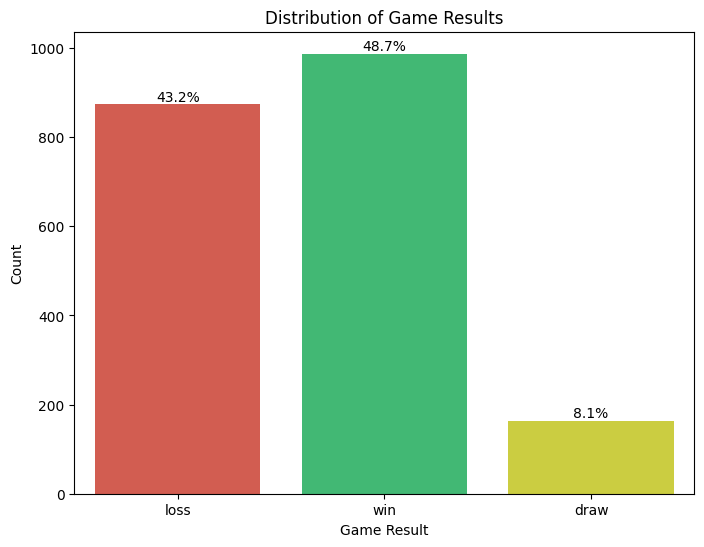

In [27]:
# Plotting the distribution of game results
plt.figure(figsize=(8, 6))
sns.countplot(x='white_outcome', data=df, hue='white_outcome', palette=OUTCOME_PALETTE)
# Adding legend and labels
plt.title('Distribution of Game Results')
plt.xlabel('Game Result')
plt.ylabel('Count')
#add a percentage on top of each bar
total = len(df)
for p in plt.gca().patches:
    height = p.get_height()
    percentage = f'{height / total:.1%}'
    plt.gca().text(p.get_x() + p.get_width() / 2., height, percentage, ha='center', va='bottom')


1) Clearly imbalanced set, as expected not many draw compared to the rest
2) Also is expected a higher win on white.

In [28]:
#add a column for winner (white, black, draw)
df['winner'] = df['white_outcome'].apply(lambda x: 'white' if x == 'win' else ('black' if x == 'loss' else 'draw'))

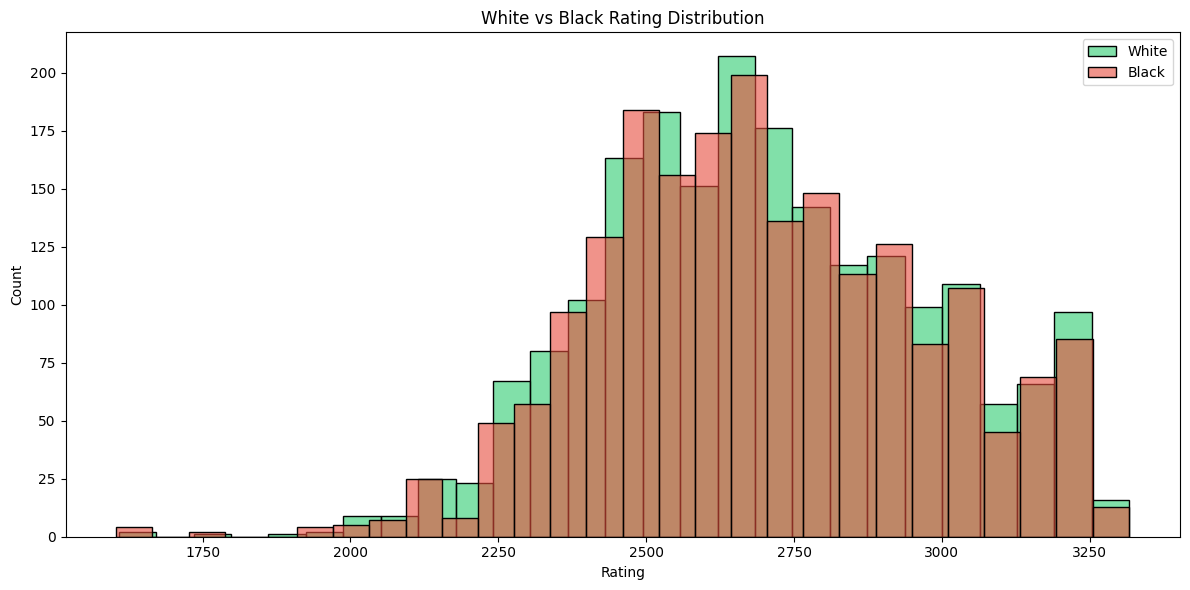

In [29]:
plt.figure(figsize=(12, 6))
sns.histplot(data=df, x='white_rating', color=WHITE_COLOR, label='White', kde=False, alpha=0.6)
sns.histplot(data=df, x='black_rating', color=BLACK_COLOR, label='Black', kde=False, alpha=0.6)
plt.title('White vs Black Rating Distribution')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()

<Axes: xlabel='rating_diff', ylabel='Count'>

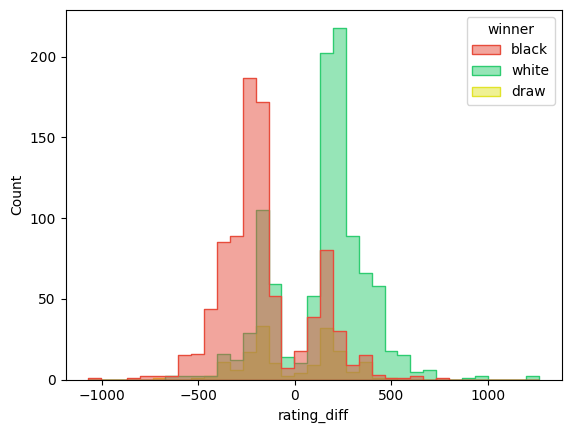

In [30]:
sns.histplot(
    data=df, 
    x='rating_diff', 
    hue='winner', 
    palette=WINNER_PALETTE,
    element='step', 
    alpha=0.5,
 )

winner,white,black,draw
round_index,,,
1,0.445545,0.490099,0.064356
2,0.436620,0.488263,0.075117
3,0.473934,0.431280,0.094787
4,0.448276,0.423645,0.128079
5,0.487179,0.451282,0.061538
6,0.562500,0.375000,0.062500
7,0.530055,0.404372,0.065574
8,0.520000,0.371429,0.108571
9,0.525316,0.411392,0.063291


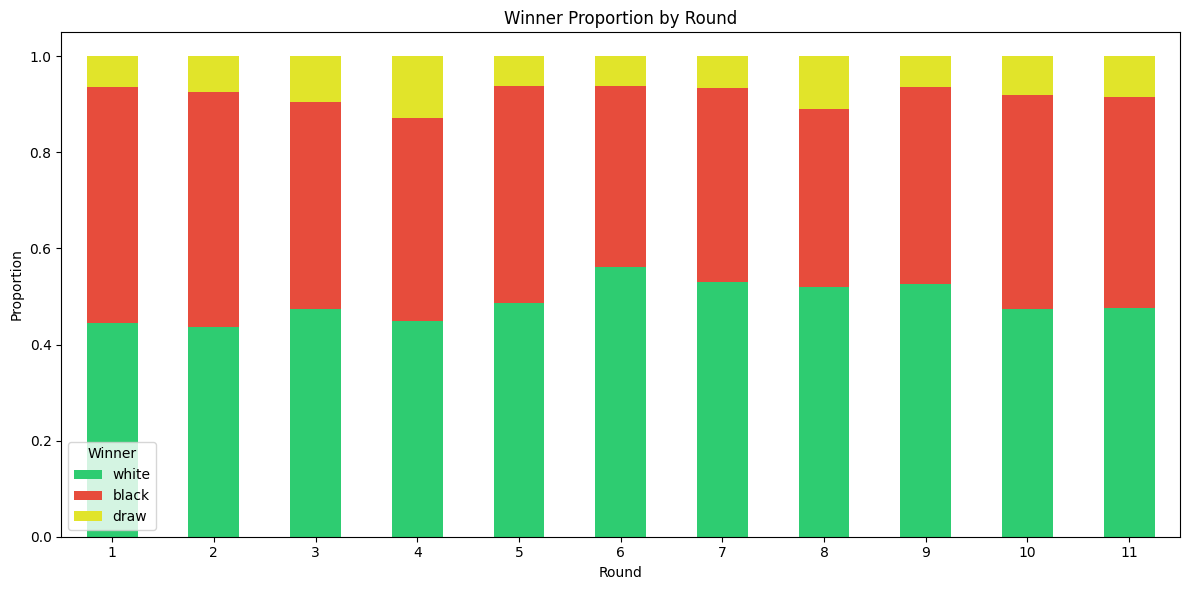

In [31]:
round_winner_prop = pd.crosstab(df['round_index'], df['winner'], normalize='index')
round_winner_prop = round_winner_prop[['white', 'black', 'draw']]

ax = round_winner_prop.plot(
    kind='bar',
    stacked=True,
    figsize=(12, 6),
    color=[WHITE_COLOR, BLACK_COLOR, DRAW_COLOR],
 )
ax.set_title('Winner Proportion by Round')
ax.set_xlabel('Round')
ax.set_ylabel('Proportion')
ax.legend(title='Winner')
plt.xticks(rotation=0)
plt.tight_layout()
round_winner_prop

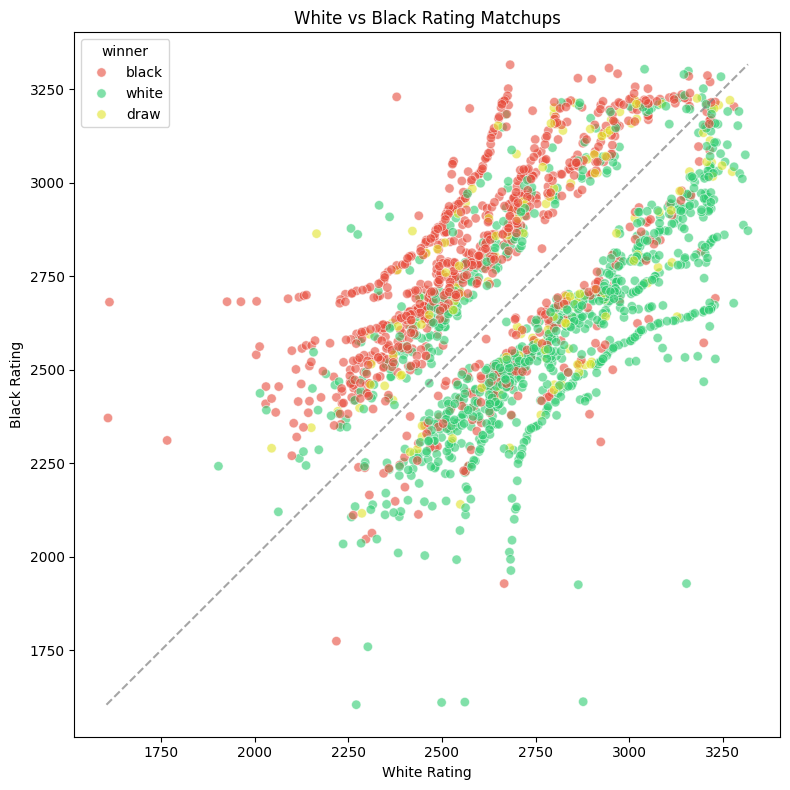

In [32]:
#make a plot of white rating vs black rating colored by winner
plot_df = df.sample(min(len(df), 2000), random_state=42)

plt.figure(figsize=(8, 8))
sns.scatterplot(
    data=plot_df,
    x='white_rating',
    y='black_rating',
    hue='winner',
    palette=WINNER_PALETTE,
    alpha=0.6,
    s=45,
 )
lims = [
    min(plot_df['white_rating'].min(), plot_df['black_rating'].min()),
    max(plot_df['white_rating'].max(), plot_df['black_rating'].max()),
]
plt.plot(lims, lims, linestyle='--', color='gray', alpha=0.7)
plt.title('White vs Black Rating Matchups')
plt.xlabel('White Rating')
plt.ylabel('Black Rating')
plt.tight_layout()

In [33]:
#since the previous plot is so beautiful, i asked the AI to make it interactive, but with hover info about the players and their ratings.

import plotly.express as px

plot_df = df.sample(min(len(df), 2000), random_state=42).copy()
lims = [
    min(plot_df['white_rating'].min(), plot_df['black_rating'].min()),
    max(plot_df['white_rating'].max(), plot_df['black_rating'].max()),
]

fig = px.scatter(
    plot_df,
    x='white_rating',
    y='black_rating',
    color='winner',
    color_discrete_map=WINNER_PALETTE,
    category_orders={'winner': ['white', 'black', 'draw']},
    custom_data=['white_player', 'white_rating', 'black_player', 'black_rating', 'winner'],
    opacity=0.6,
    title='White vs Black Rating Matchups',
)

fig.update_traces(
    marker=dict(size=9),
    hovertemplate=(
        'White: %{customdata[0]} (%{customdata[1]:.0f})<br>'
        'Black: %{customdata[2]} (%{customdata[3]:.0f})<br>'
        'Winner: %{customdata[4]}<extra></extra>'
    ),
)

fig.add_shape(
    type='line',
    x0=lims[0],
    y0=lims[0],
    x1=lims[1],
    y1=lims[1],
    line=dict(color='gray', dash='dash'),
)

fig.update_layout(
    xaxis_title='White Rating',
    yaxis_title='Black Rating',
    width=800,
    height=800,
    legend_title_text='Winner',
)

fig.show()

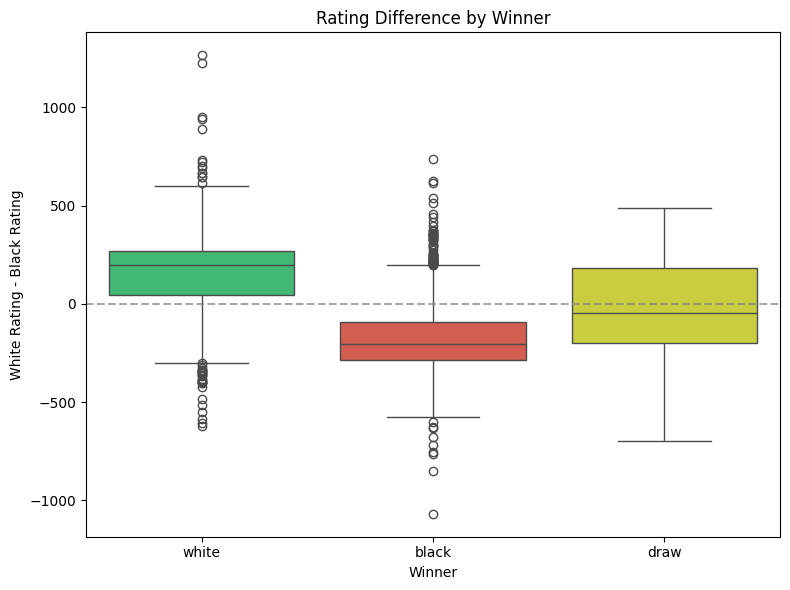

In [34]:
plt.figure(figsize=(8, 6))
sns.boxplot(
    data=df,
    x='winner',
    y='rating_diff',
    hue='winner',
    order=['white', 'black', 'draw'],
    hue_order=['white', 'black', 'draw'],
    palette=WINNER_PALETTE,
    dodge=False,
    legend=False,
 )
plt.axhline(0, linestyle='--', color='gray', alpha=0.7)
plt.title('Rating Difference by Winner')
plt.xlabel('Winner')
plt.ylabel('White Rating - Black Rating')
plt.tight_layout()

,round_index,white_rating,black_rating
0,1,2702.524752,2702.816832
1,2,2698.779343,2698.826291
2,3,2684.274882,2703.127962
3,4,2699.448276,2698.408867
4,5,2707.302564,2691.892308
5,6,2701.661458,2693.453125
6,7,2709.229508,2692.617486
7,8,2702.457143,2697.382857
8,9,2711.196203,2694.987342
9,10,2697.566667,2705.173333


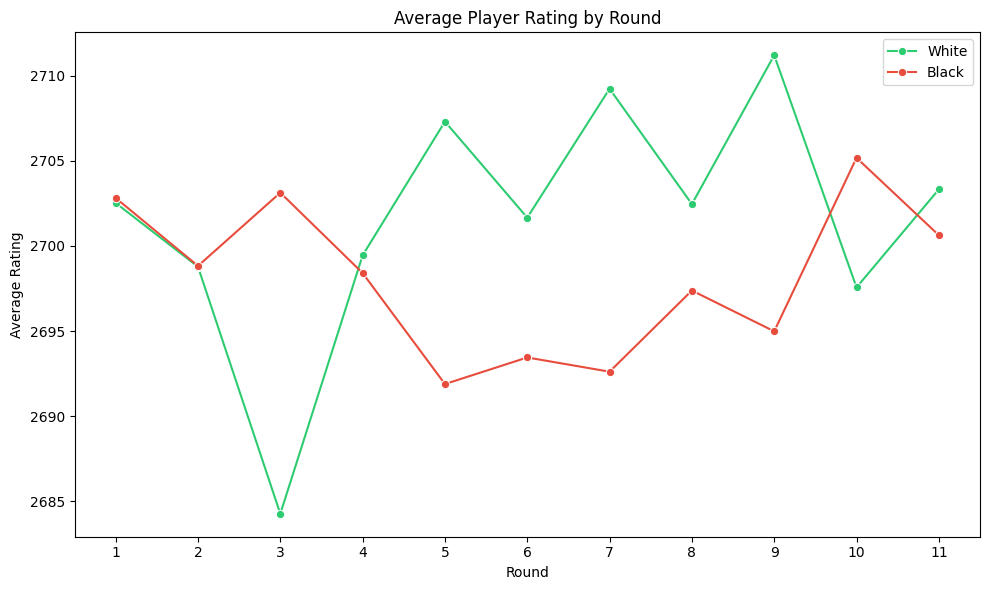

In [35]:
round_rating_means = df.groupby('round_index')[['white_rating', 'black_rating']].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.lineplot(data=round_rating_means, x='round_index', y='white_rating', marker='o', color=WHITE_COLOR, label='White')
sns.lineplot(data=round_rating_means, x='round_index', y='black_rating', marker='o', color=BLACK_COLOR, label='Black')
plt.title('Average Player Rating by Round')
plt.xlabel('Round')
plt.ylabel('Average Rating')
plt.xticks(sorted(df['round_index'].unique()))
plt.tight_layout()
round_rating_means

winner,white,black,draw
game_opening,,,
Undefined,0.153846,0.692308,0.153846
Sicilian-Defense-Smith-Morra-Gambit-2...cxd4-3.Qxd4-Nc6,0.666667,0.166667,0.166667
Kings-Pawn-Opening-Kings-Knight-Elephant-Paulsen-Countergambit-4.Qe2,0.166667,0.666667,0.166667
Kings-Pawn-Opening-Kings-Knight-Variation,0.666667,0.333333,0.000000
Kings-Pawn-Opening,1.000000,0.000000,0.000000
Queens-Pawn-Opening-Chigorin-Variation...3.Bf4-a6-4.e3-e6,0.800000,0.000000,0.200000
Caro-Kann-Defense-2.Nf3-d5-3.d3,0.800000,0.200000,0.000000
Nimzo-Indian-Defense-Bishop-Attack-Classical-Botvinnik-System...8.Bxc4-c5-9.Nf3-Qc7,0.250000,0.500000,0.250000
Sicilian-Defense-Open-Dragon-Variation-6.Be3-Nc6-7.f3,0.250000,0.500000,0.250000


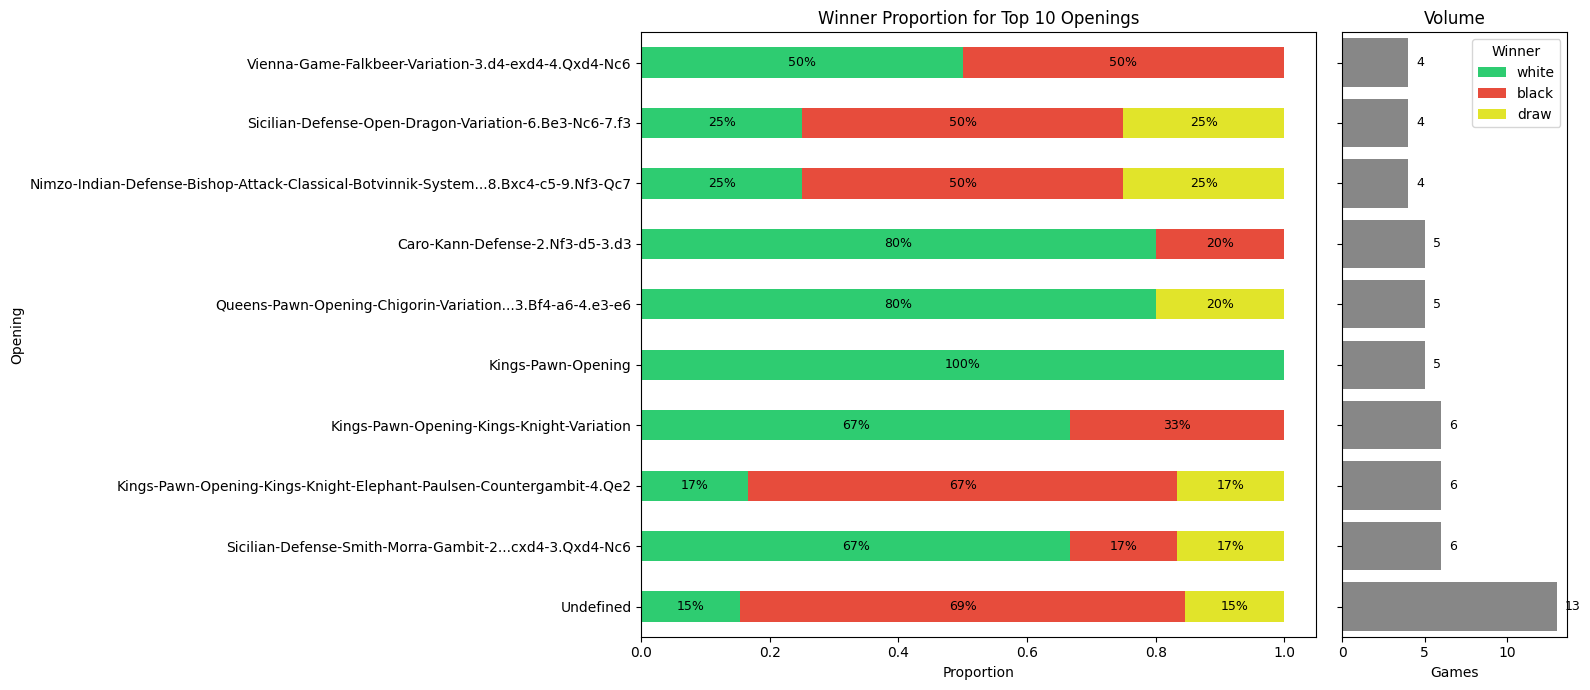

In [36]:
opening_label = df['game_opening'].str.replace('https://www.chess.com/openings/', '', regex=False)
top_opening_counts = opening_label.value_counts().head(10)
top_openings = top_opening_counts.index
opening_plot_df = df.assign(game_opening_label=opening_label)
opening_plot_df = opening_plot_df[opening_plot_df['game_opening_label'].isin(top_openings)]
opening_winner_prop = pd.crosstab(opening_plot_df['game_opening_label'], opening_plot_df['winner'], normalize='index')
opening_winner_prop = opening_winner_prop.reindex(index=top_openings, columns=['white', 'black', 'draw'], fill_value=0)

fig, (ax1, ax2) = plt.subplots(
    ncols=2,
    figsize=(16, 7),
    gridspec_kw={'width_ratios': [3, 1]},
    sharey=True,
 )

opening_winner_prop.plot(
    kind='barh',
    stacked=True,
    color=[WHITE_COLOR, BLACK_COLOR, DRAW_COLOR],
    ax=ax1,
 )
ax1.set_title('Winner Proportion for Top 10 Openings')
ax1.set_xlabel('Proportion')
ax1.set_ylabel('Opening')
legend_handles, legend_labels = ax1.get_legend_handles_labels()
ax1.get_legend().remove()

for row_index, opening in enumerate(opening_winner_prop.index):
    cumulative_width = 0.0
    for column, color in zip(['white', 'black', 'draw'], [WHITE_COLOR, BLACK_COLOR, DRAW_COLOR]):
        value = opening_winner_prop.loc[opening, column]
        if value > 0.04:
            ax1.text(
                cumulative_width + value / 2,
                row_index,
                f'{value:.0%}',
                ha='center',
                va='center',
                fontsize=9,
                color='black',
            )
        cumulative_width += value

ax2.barh(top_openings, top_opening_counts.values, color='dimgray', alpha=0.8)
ax2.set_title('Volume')
ax2.set_xlabel('Games')
ax2.set_ylabel('')
ax2.legend(legend_handles, legend_labels, title='Winner', loc='upper right')

for row_index, count in enumerate(top_opening_counts.values):
    ax2.text(count + 0.5, row_index, str(count), va='center', fontsize=9)

plt.tight_layout()
opening_winner_prop

Please note that this is only the top 10 opennings, the repertoire is much bigger (around 1.6k)

In [37]:
df.game_opening.value_counts()

game_opening
https://www.chess.com/openings/Undefined                                                                   13
https://www.chess.com/openings/Sicilian-Defense-Smith-Morra-Gambit-2...cxd4-3.Qxd4-Nc6                      6
https://www.chess.com/openings/Kings-Pawn-Opening-Kings-Knight-Elephant-Paulsen-Countergambit-4.Qe2         6
https://www.chess.com/openings/Kings-Pawn-Opening-Kings-Knight-Variation                                    6
https://www.chess.com/openings/Kings-Pawn-Opening                                                           5
                                                                                                           ..
https://www.chess.com/openings/Caro-Kann-Defense-Main-Line-4...Nf6-5.Ng3                                    1
https://www.chess.com/openings/Benko-Gambit-4.Qc2                                                           1
https://www.chess.com/openings/Benko-Gambit-Half-Accepted-Pawn-Return-Variation...6.Nc3-d6-7.a4-g6-8.a5    

In [38]:
df.game_opening.nunique()

1782

# Observations:

About the data:
1. The data is very clean from the beginning, no need to do any extra cleaning.
1. There is no duplicates in names, this could be due to the size of the data, and thus for good data practice we will use the uuid instead.

About the games:
1. The distribution shows that white has a slightly higher rate than black for winning, and draws are the least common.
1. The scatter plot of white vs black ratings colored by winner indicates that higher-rated players tend to win more often, but there are also many cases where lower-rated players win.
1. The draws are more likely when the rating is close.
    